# 03 — Baseline Model (Linear Regression)

**Objective:** Train a simple Linear Regression model to predict `ClosePrice`  
and establish a **baseline R² score** that future models must beat.

**What is Linear Regression?**  
It draws the best-fit straight line through the data.  
The formula is: `ClosePrice = w1*LivingArea + w2*Bedrooms + ... + bias`  
where the model learns the weights (w1, w2, etc.) from the training data.

## 1 — Imports

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2 — Load the Cleaned Data

We load the `train.csv` and `test.csv` files created in `02_preprocessing.ipynb`.  
These already have missing values filled, categories encoded, and numeric features scaled.

In [3]:
# Load train and test data
DATA_DIR = os.path.join(os.getcwd(), 'Data')
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f'Training set: {len(train_df):,} rows')
print(f'Test set:     {len(test_df):,} rows')
train_df.head()

Training set: 56,096 rows
Test set:     12,544 rows


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,Stories,DaysOnMarket,City,PostalCode,ClosePrice
0,-0.048335,0.562856,1.044790,-0.014421,1.726299,0.000687,1.544936,0.030808,502,316,815000.0
1,-0.048335,0.562856,1.044790,-0.014421,1.726299,0.000687,1.544936,4.234854,502,316,810000.0
2,1.666837,0.562856,1.044790,-0.013947,1.579753,0.282062,1.544936,-0.680646,697,698,2100000.0
3,0.074316,-0.495430,-1.954584,-0.006452,0.370742,0.000687,1.544936,-1.456777,254,1488,1950000.0
4,0.407227,0.562856,0.294946,-0.014244,0.334105,0.282062,-0.647276,-0.680646,692,1374,2340000.0


## 3 — Separate Features (X) and Target (y)

- **X** = the input features the model uses to make predictions
- **y** = the target value (`ClosePrice`) the model is trying to predict

In [4]:
# The target column we want to predict
target = 'ClosePrice'

# X = all columns EXCEPT ClosePrice
# y = just ClosePrice
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print(f'Features (X): {list(X_train.columns)}')
print(f'Number of features: {X_train.shape[1]}')

Features (X): ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'DaysOnMarket', 'City', 'PostalCode']
Number of features: 10


## 4 — Train the Linear Regression Model

This is surprisingly simple — just two lines!  
1. Create the model  
2. Fit (train) it on the training data

In [5]:
# Create the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print('Model trained!')

Model trained!


## 5 — Make Predictions on the Test Set

In [10]:
# Use the trained model to predict ClosePrice for the test set
y_pred = model.predict(X_test)

# Show a few examples: actual price vs predicted price
results = pd.DataFrame({
    'Actual Price':    y_test.values,
    'Predicted Price': y_pred.round(0)
})
results['Difference'] = results['Actual Price'] - results['Predicted Price']

print('Sample predictions (first 10):')
results.head(10)

Sample predictions (first 10):


,Actual Price,Predicted Price,Difference
0,3000000.0,1512460.0,1487540.0
1,7750000.0,3624690.0,4125310.0
2,575000.0,623044.0,-48044.0
3,1810000.0,1092555.0,717445.0
4,1135000.0,1917721.0,-782721.0
...,...,...,...
95,2000000.0,1988154.0,11846.0
96,1315000.0,1184274.0,130726.0
97,1601928.0,781127.0,820801.0
98,319000.0,914030.0,-595030.0


## 6 — Evaluate with R² Score

**R² (R-squared)** measures how well the model explains the data:  
- **R² = 1.0** → perfect predictions  
- **R² = 0.0** → the model is no better than just guessing the average price  
- **R² < 0** → the model is worse than guessing the average (very bad)

In [11]:
# Calculate R² on the test set
r2 = r2_score(y_test, y_pred)

print('=' * 40)
print(f'  BASELINE R² SCORE: {r2:.4f}')
print('=' * 40)
print(f'\nThe model explains {r2 * 100:.1f}% of the')
print(f'variation in ClosePrice.')

  BASELINE R² SCORE: 0.4951

The model explains 49.5% of the
variation in ClosePrice.


## 7 — Visualize: Actual vs Predicted

If the model were perfect, all dots would sit on the red diagonal line.  
Points far from the line are houses the model priced incorrectly.

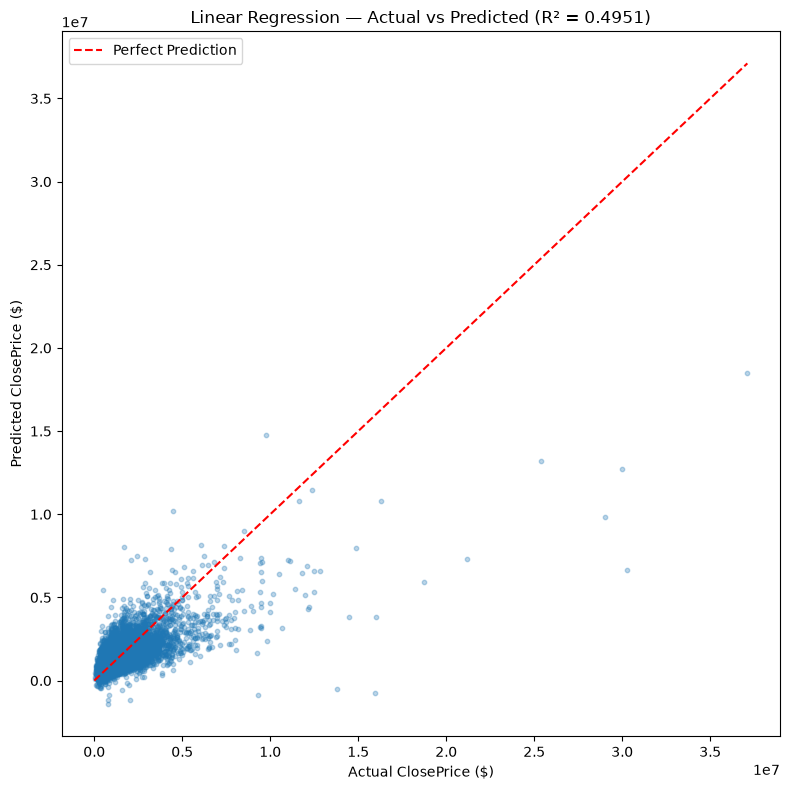

In [12]:
plt.figure(figsize=(8, 8))

# Scatter plot of actual vs predicted prices
plt.scatter(y_test, y_pred, alpha=0.3, s=10)

# Draw a red diagonal line (perfect predictions would land here)
max_price = max(y_test.max(), y_pred.max())
plt.plot([0, max_price], [0, max_price], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual ClosePrice ($)')
plt.ylabel('Predicted ClosePrice ($)')
plt.title(f'Linear Regression — Actual vs Predicted (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

## 8 — Feature Importance (Model Coefficients)

In Linear Regression, each feature gets a **coefficient** (weight).  
Larger absolute values mean that feature has more influence on the predicted price.  

Since our numeric features are scaled, the coefficients are directly comparable.

In [13]:
# Create a table of feature names and their coefficients
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': model.coef_
})

# Sort by absolute value (biggest influence first)
coef_df['Abs Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs Coefficient', ascending=False)
coef_df = coef_df.drop(columns=['Abs Coefficient'])

print('Feature coefficients (sorted by importance):')
print(coef_df.to_string(index=False))
print(f'\nBias (intercept): ${model.intercept_:,.0f}')

Feature coefficients (sorted by importance):
              Feature    Coefficient
           LivingArea  929510.608600
            YearBuilt -300418.949934
BathroomsTotalInteger  209704.158972
        BedroomsTotal -137292.845544
              Stories -128973.758217
         DaysOnMarket  -66856.044754
         GarageSpaces  -13281.598998
    LotSizeSquareFeet    -170.274914
           PostalCode     106.389710
                 City     103.917220

Bias (intercept): $1,138,336


## 9 — Baseline Results Summary

| Metric | Value |
|--------|-------|
| **Model** | Linear Regression |
| **Training Months** | Jan–May 2024 |
| **Test Month** | June 2024 |
| **R² Score** | *(see output above)* |

### What's next (Week 5):
Try **Decision Tree** and **Random Forest** regressors and compare their R² against this baseline.